# R-peak detection on ecgrdvq ECG

This notebook loads an ECG from the **ecgrdvq** database and applies the same R-peak detection pipeline used in `R-peaks.ipynb` (wavelet denoising → slope → segmented K-Means → region extraction → R-peak selection → refractory filter).

In [23]:
import pandas as pd
import numpy as np
import wfdb
import pywt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

## 1. Load a record from ecgrdvq

In [24]:
def load_ecgrdvq_record(drug_name: str = "Ranolazine"):
    """Load a single ECG record from the ecgrdvq database for a given drug."""
    csv_url = "https://physionet.org/files/ecgrdvq/1.0.0/SCR-002.Clinical.Data.csv"
    clinical_df = pd.read_csv(csv_url)

    # Check available drugs
    available_drugs = clinical_df["EXTRT"].unique()
    print(available_drugs)

    # Filter by drug and take the first available record
    record_row = clinical_df[clinical_df["EXTRT"] == drug_name].iloc[0]

    subject_id = str(int(record_row["RANDID"]))  # Subject folder name
    record_id = record_row["EGREFID"]            # WFDB record name (without extension)

    pn_dir = f"ecgrdvq/1.0.0/raw/{subject_id}/"
    record = wfdb.rdrecord(record_id, pn_dir=pn_dir)

    # Use the first ECG channel by default
    ecg = record.p_signal[:, 0].astype(float)
    fs = float(record.fs)

    info = {
        "drug": drug_name,
        "subject_id": subject_id,
        "record_id": record_id,
    }

    print(
        f"Loaded record {record_id} "
        f"(Drug: {drug_name}, Subject: {subject_id}), "
        f"fs = {fs} Hz, N = {len(ecg)} samples"
    )

    return ecg, fs, record, info


# Load one example record
ecg, fs, record, info = load_ecgrdvq_record("Quinidine Sulph")
duration_sec = len(ecg) / fs
print(f"Duration: {duration_sec} seconds")

['Ranolazine' 'Verapamil HCL' 'Placebo' 'Quinidine Sulph' 'Dofetilide']
Loaded record 57c59f08-c58d-4a38-afa3-1a9233697446 (Drug: Quinidine Sulph, Subject: 1001), fs = 1000.0 Hz, N = 10000 samples
Duration: 10.0 seconds


### Quick look at the raw ECG

We plot the first 10 seconds to get a sense of the morphology and noise level.

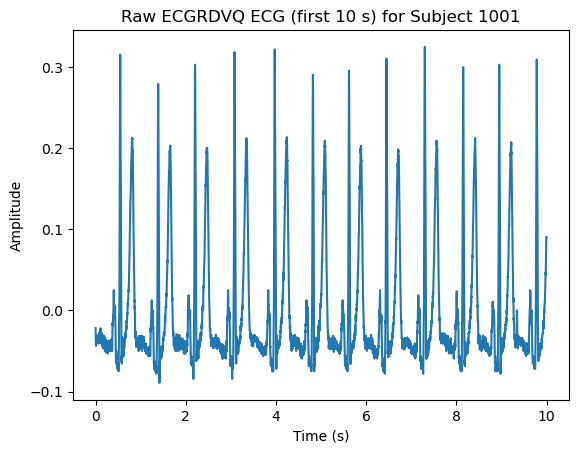

In [25]:
show_sec = 10
show_samples = int(show_sec * fs)
t = np.arange(show_samples) / fs

plt.figure()
plt.plot(t, ecg[:show_samples])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Raw ECGRDVQ ECG (first 10 s) for Subject {info["subject_id"]}")
plt.show()

### Frequency Plot with Furios Transform

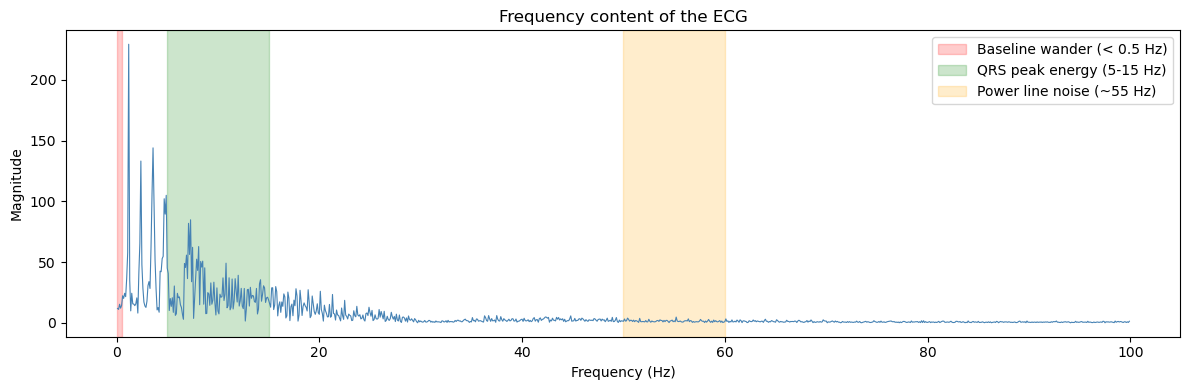

In [26]:
fft_vals = np.abs(fft(ecg))
freqs    = fftfreq(len(ecg), d=1/fs)

pos_mask = (freqs > 0) & (freqs < 100)

plt.figure(figsize=(12, 4))
plt.plot(freqs[pos_mask], fft_vals[pos_mask], 'steelblue', linewidth=0.8)
plt.axvspan(0,  0.5, alpha=0.2, color='red',    label='Baseline wander (< 0.5 Hz)')
plt.axvspan(5,  15,  alpha=0.2, color='green',  label='QRS peak energy (5-15 Hz)')
plt.axvspan(50, 60,  alpha=0.2, color='orange', label='Power line noise (~55 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency content of the ECG')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Wavelet denoising and slope

We apply the same wavelet filter (`sym8`, keep detail levels 3–8) and compute the absolute slope.

In [27]:
wavelet = 'sym8'
max_safe_level = pywt.dwt_max_level(len(ecg), pywt.Wavelet(wavelet).dec_len)
print(f"A max level of {max_safe_level} can be used safely")

A max level of 9 can be used safely


In [28]:
seg_time = np.arange(len(ecg)) / fs

# Decompose with sym8 wavelet at 8 levels
wavelet = 'sym8'
level   = 9
coeffs  = pywt.wavedec(ecg, wavelet, level=level)

# Print the actual frequency bands before doing anything
def print_wavelet_bands(fs, level):
    nyquist = fs / 2
    print(f"\nWavelet bands for fs={fs}Hz, {level} levels:")
    print(f"  cA{level}: 0.00 - {nyquist/2**level:.2f} Hz  ← approximation")
    for n in range(level, 0, -1):
        low  = nyquist / 2**n
        high = nyquist / 2**(n-1)
        print(f"  cD{n}: {low:.2f} - {high:.2f} Hz  "
              f"(coeffs index {level-n+1})")

print_wavelet_bands(fs=fs, level=level)


Wavelet bands for fs=1000.0Hz, 9 levels:
  cA9: 0.00 - 0.98 Hz  ← approximation
  cD9: 0.98 - 1.95 Hz  (coeffs index 1)
  cD8: 1.95 - 3.91 Hz  (coeffs index 2)
  cD7: 3.91 - 7.81 Hz  (coeffs index 3)
  cD6: 7.81 - 15.62 Hz  (coeffs index 4)
  cD5: 15.62 - 31.25 Hz  (coeffs index 5)
  cD4: 31.25 - 62.50 Hz  (coeffs index 6)
  cD3: 62.50 - 125.00 Hz  (coeffs index 7)
  cD2: 125.00 - 250.00 Hz  (coeffs index 8)
  cD1: 250.00 - 500.00 Hz  (coeffs index 9)


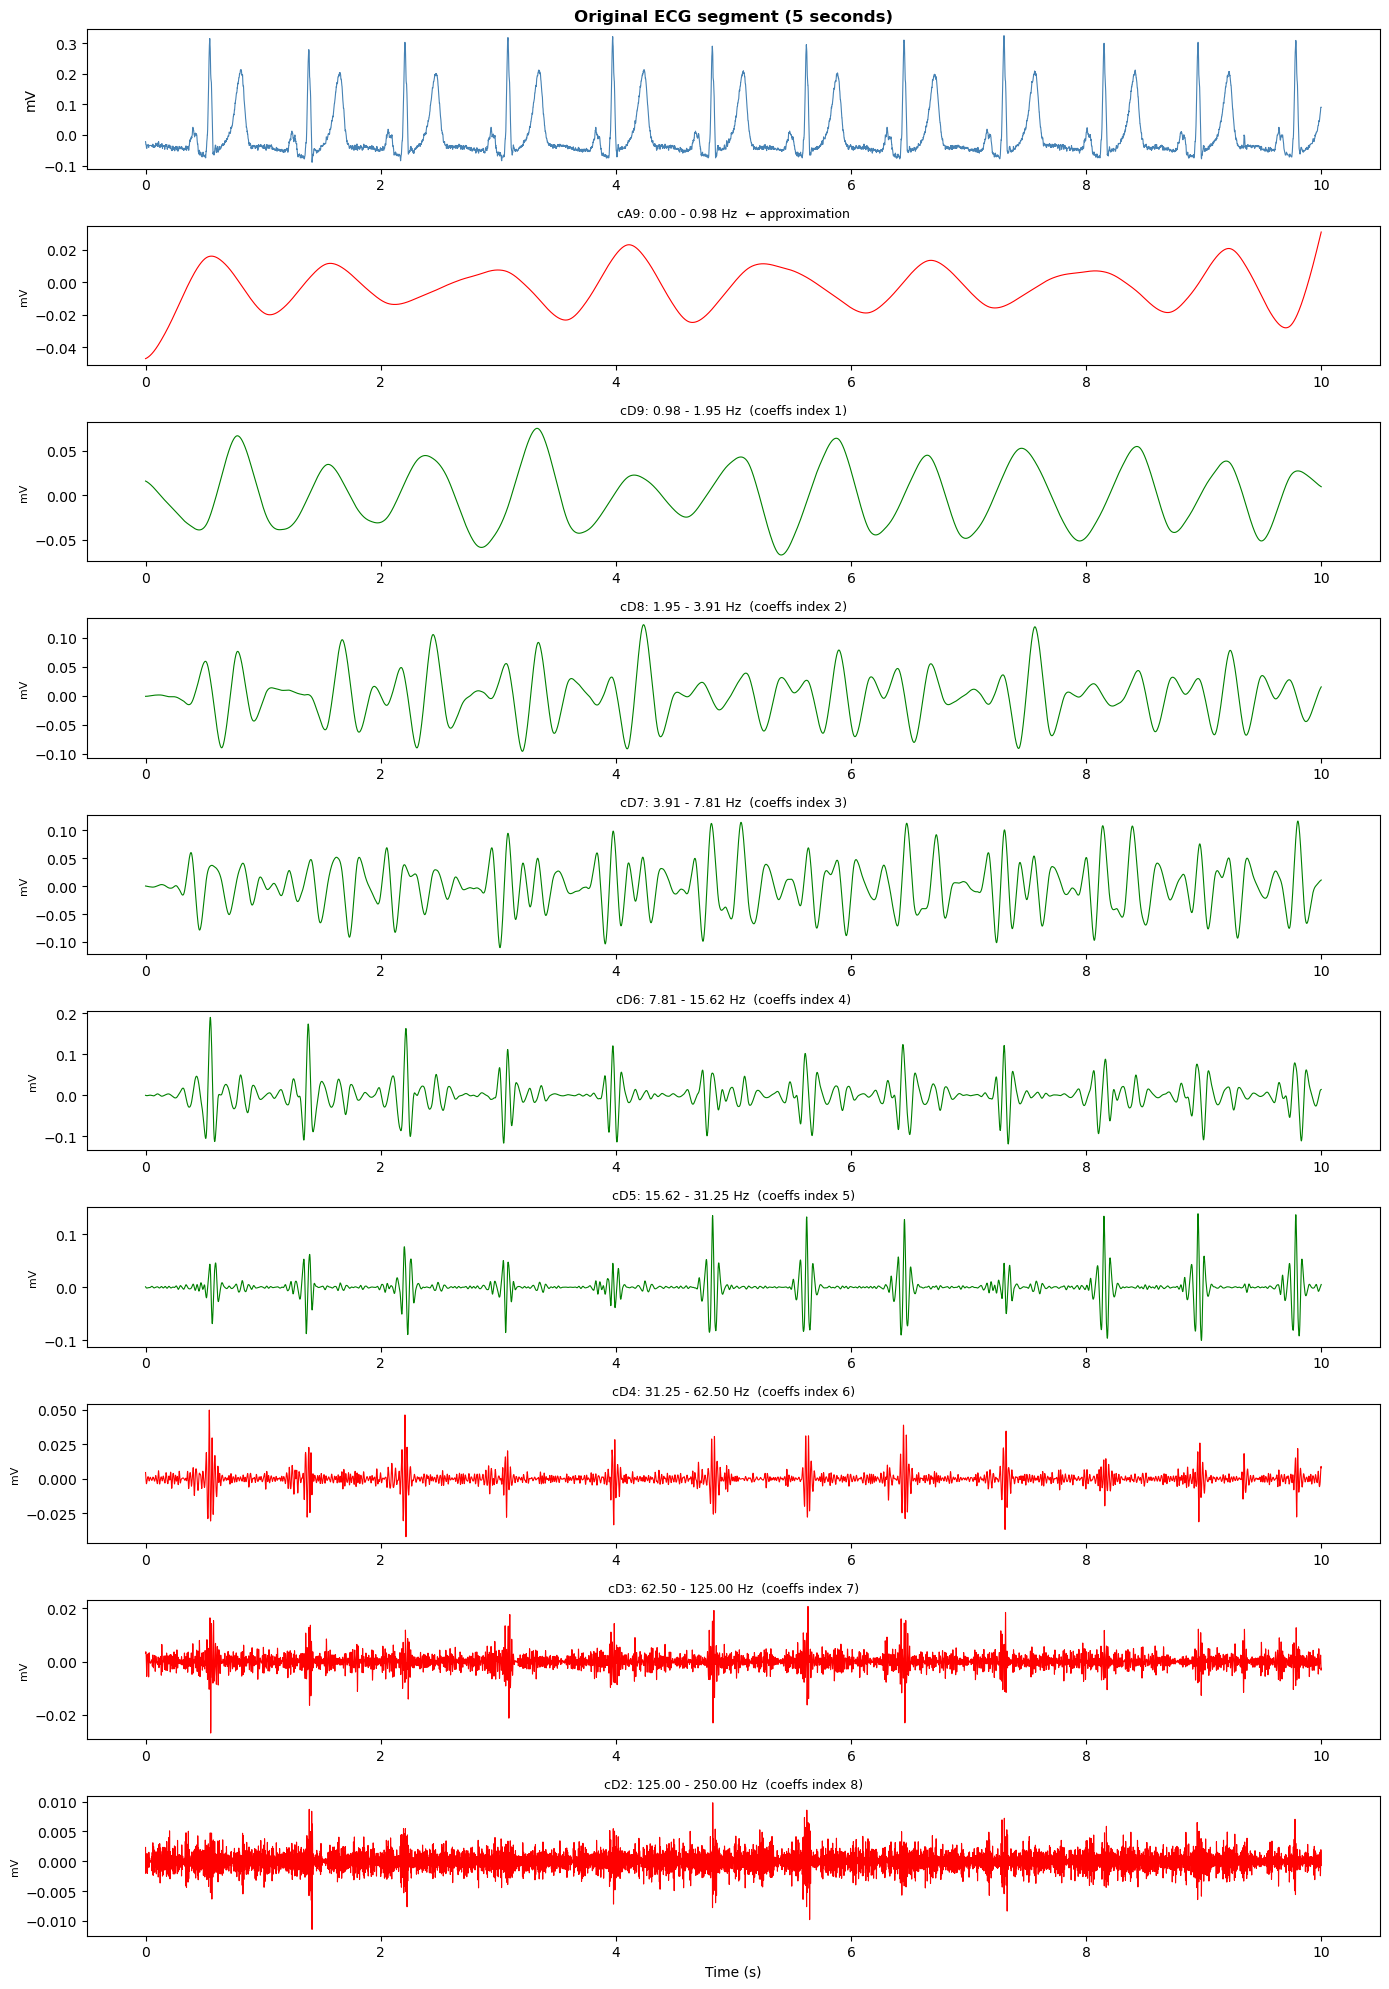

In [29]:
# Plot each level individually
fig, axes = plt.subplots(10, 1, figsize=(14, 20))

# Original signal
axes[0].plot(seg_time, ecg, 'steelblue', linewidth=0.8)
axes[0].set_title('Original ECG segment (5 seconds)', fontweight='bold')
axes[0].set_ylabel('mV')

# Reconstruct each level individually to see its contribution
level_names = ['cA9: 0.00 - 0.98 Hz  ← approximation',
                'cD9: 0.98 - 1.95 Hz  (coeffs index 1)',
                'cD8: 1.95 - 3.91 Hz  (coeffs index 2)',
                'cD7: 3.91 - 7.81 Hz  (coeffs index 3)',
                'cD6: 7.81 - 15.62 Hz  (coeffs index 4)',
                'cD5: 15.62 - 31.25 Hz  (coeffs index 5)',
                'cD4: 31.25 - 62.50 Hz  (coeffs index 6)',
                'cD3: 62.50 - 125.00 Hz  (coeffs index 7)',
                'cD2: 125.00 - 250.00 Hz  (coeffs index 8)',
                'cD1: 250.00 - 500.00 Hz  (coeffs index 9)']

colors = ['red', 'green', 'green', 'green', 'green', 'green', 'red', 'red', 'red']

for i, (name, color) in enumerate(zip(level_names, colors)):
    # Reconstruct signal from ONLY this level
    zero_coeffs = [np.zeros_like(c) for c in coeffs]
    zero_coeffs[i] = coeffs[i]
    reconstructed = pywt.waverec(zero_coeffs, wavelet)[:len(ecg)]
    
    axes[i+1].plot(seg_time, reconstructed, color=color, linewidth=0.8)
    axes[i+1].set_title(name, fontsize=9)
    axes[i+1].set_ylabel('mV', fontsize=8)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

### Reconstruct clean signal

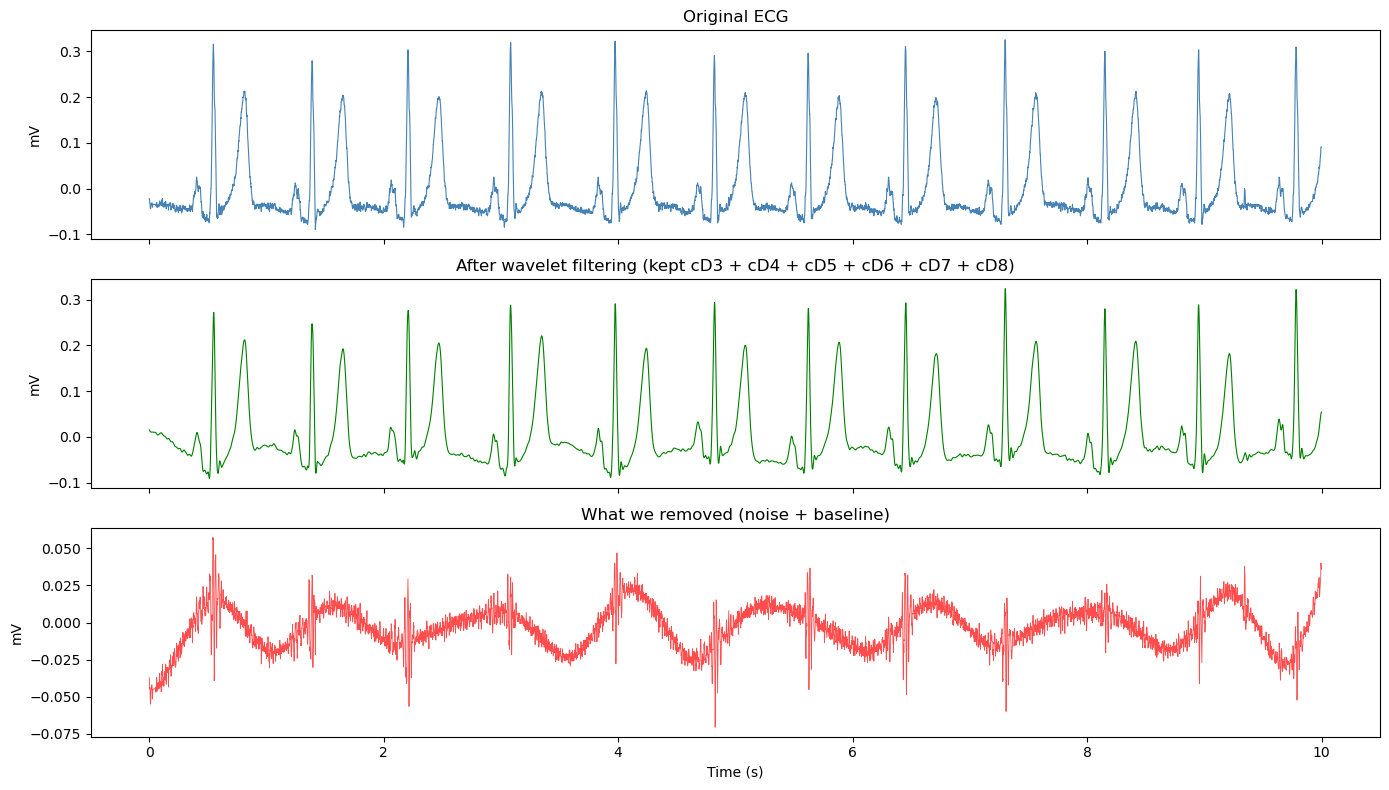

In [ ]:
keep_levels = [1, 2, 3, 4, 5]  # cD9 through cD5

clean_coeffs = [np.zeros_like(c) for c in coeffs]

for k in keep_levels:
    clean_coeffs[k] = coeffs[k]

clean_signal = pywt.waverec(clean_coeffs, wavelet)[:len(ecg)]

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(seg_time, ecg, 'steelblue', linewidth=0.8)
axes[0].set_title('Original ECG')
axes[0].set_ylabel('mV')

axes[1].plot(seg_time, clean_signal, 'green', linewidth=0.8)
axes[1].set_title('After wavelet filtering (kept cD3 + cD4 + cD5 + cD6 + cD7 + cD8)')
axes[1].set_ylabel('mV')

axes[2].plot(seg_time, ecg - clean_signal, 'red', linewidth=0.6, alpha=0.7)
axes[2].set_title('What we removed (noise + baseline)')
axes[2].set_ylabel('mV')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

Signal polarity: positive


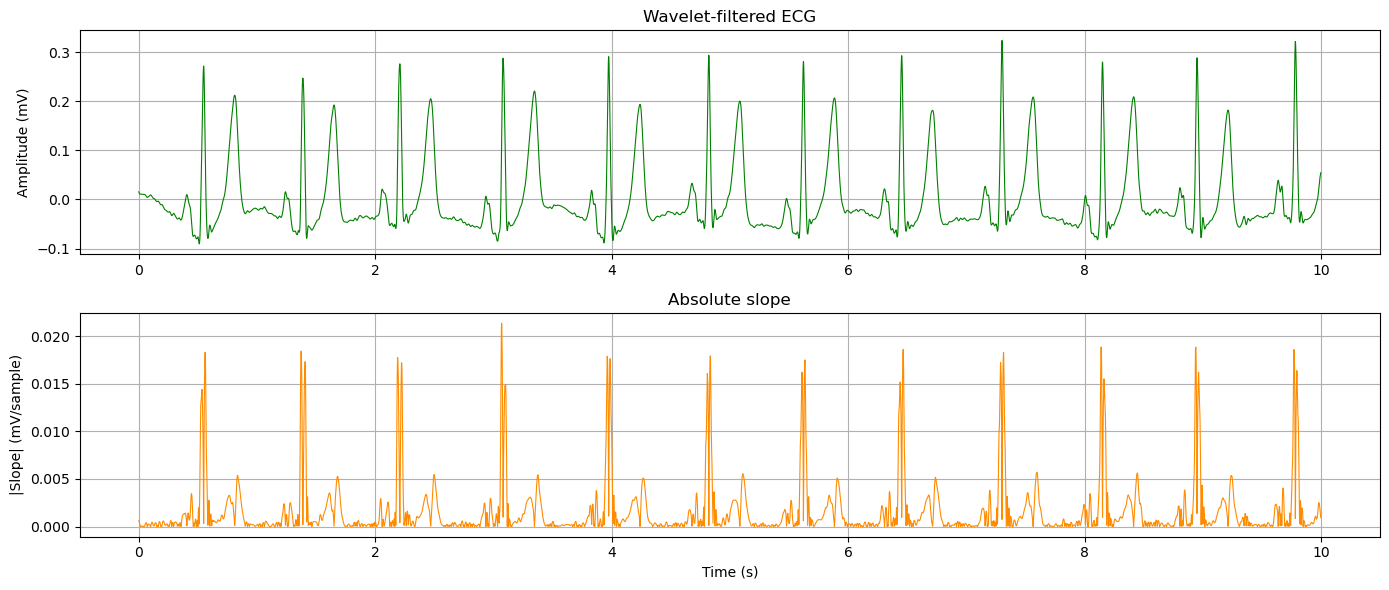

In [31]:
# Polarity detection
ref = clean_signal[:int(10 * fs)]
polarity = 1 if np.max(ref) >= np.abs(np.min(ref)) else -1
clean_signal = clean_signal * polarity               # flip if inverted

print(f"Signal polarity: {'positive' if polarity == 1 else 'negative'}")

# Absolute slope
abs_slope = np.abs(np.gradient(clean_signal))

# Visualise on the first 10 seconds
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(t, clean_signal, 'green', linewidth=0.8)
plt.title('Wavelet-filtered ECG')
plt.ylabel('Amplitude (mV)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, abs_slope[:show_samples], color='darkorange', linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel('|Slope| (mV/sample)')
plt.title('Absolute slope')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Segmented K-Means to obtain a QRS mask

We reuse the segmented K-Means logic from `R-peaks.ipynb` to classify high-slope samples as QRS.

Total samples: 10000
QRS-labeled samples: 563 (5.63% of signal)


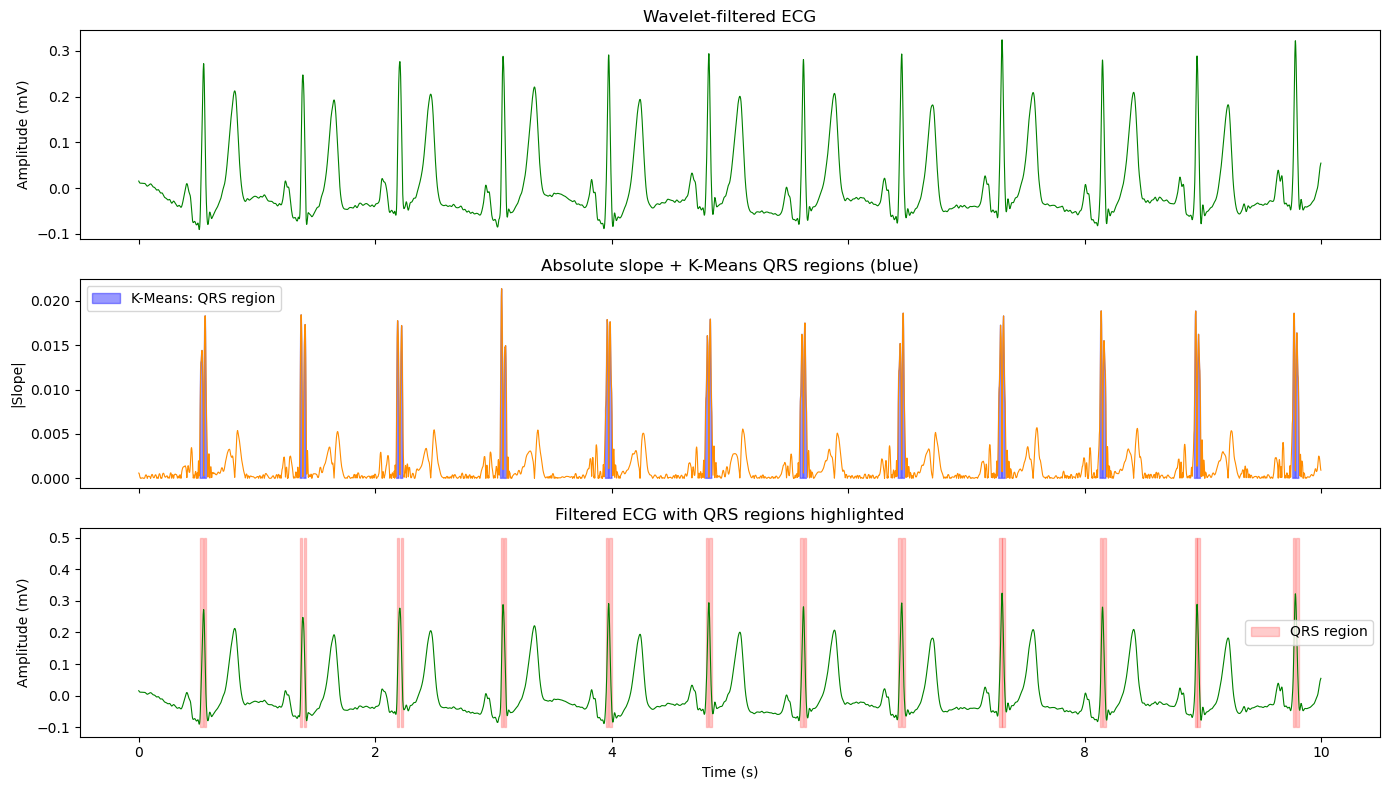

In [32]:
segment_len = int(60 * fs)  # 1-minute segments
n = len(abs_slope)
qrs_mask = np.zeros(n, dtype=bool)

for start in range(0, n, segment_len):
    end = min(start + segment_len, n)
    segment = abs_slope[start:end].reshape(-1, 1)

    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels = kmeans.fit_predict(segment)

    # QRS cluster = the one with the higher centroid
    qrs_cluster = np.argmax(kmeans.cluster_centers_.flatten())
    qrs_mask[start:end] = (labels == qrs_cluster)

print(f"Total samples: {n}")
print(f"QRS-labeled samples: {qrs_mask.sum()} ({100*qrs_mask.mean():.2f}% of signal)")

# Visualise mask over first 10 seconds
mask_window = qrs_mask[:show_samples]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t, clean_signal[:show_samples], 'green', linewidth=0.8)
axes[0].set_title('Wavelet-filtered ECG')
axes[0].set_ylabel('Amplitude (mV)')

axes[1].plot(t, abs_slope[:show_samples], 'darkorange', linewidth=0.8)
axes[1].fill_between(t, 0, abs_slope[:show_samples],
                     where=qrs_mask[:show_samples],
                     color='blue', alpha=0.4, label='K-Means: QRS region')
axes[1].set_title('Absolute slope + K-Means QRS regions (blue)')
axes[1].set_ylabel('|Slope|')
axes[1].legend()

axes[2].plot(t, clean_signal[:show_samples], 'green', linewidth=0.8)
axes[2].fill_between(t, -0.1, 0.5,
                     where=qrs_mask[:show_samples],
                     color='red', alpha=0.2, label='QRS region')
axes[2].set_title('Filtered ECG with QRS regions highlighted')
axes[2].set_ylabel('Amplitude (mV)')
axes[2].set_xlabel('Time (s)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. Extract QRS regions and R-peaks

We directly port the `extract_regions`, `detect_r_peaks`, and `apply_refractory` functions from `R-peaks.ipynb`.

In [33]:
# 1. Convert mask to list of (start, end) regions 
def extract_regions(mask: np.ndarray, fs: int, min_ms: int = 0, max_ms: int = 250):
    """Find contiguous True runs in the mask with duration between min_ms and max_ms."""
    min_samples = int(min_ms / 1000 * fs)
    max_samples = int(max_ms / 1000 * fs)

    regions = []
    in_region = False
    start = 0

    for i, val in enumerate(mask):
        if val and not in_region:
            start = i
            in_region = True
        elif not val and in_region:
            duration = i - start
            if min_samples <= duration <= max_samples:
                regions.append((start, i))
            in_region = False

    # Handle region at the very end of signal
    if in_region:
        duration = len(mask) - start
        if min_samples <= duration <= max_samples:
            regions.append((start, len(mask)))

    return regions


# 2. Find maximum amplitude sample within each region
def detect_r_peaks(signal: np.ndarray, regions):
    """Within each QRS region, take the sample with highest amplitude as the R-peak."""
    r_peaks = []
    for start, end in regions:
        segment = signal[start:end]
        if len(segment) == 0:
            continue
        peak_in_seg = int(np.argmax(segment))
        r_peaks.append(start + peak_in_seg)
    return np.array(r_peaks, dtype=int)


# 3. Refractory period filter 
def apply_refractory(peaks: np.ndarray, signal: np.ndarray, fs: float, refractory_ms: int = 200):
    """Enforce a minimum RR interval (keep the higher-amplitude peak if two are too close)."""
    if len(peaks) == 0:
        return peaks

    refractory_samples = int(refractory_ms / 1000 * fs)
    filtered = [int(peaks[0])]

    for peak in peaks[1:]:
        peak = int(peak)
        if peak - filtered[-1] >= refractory_samples:
            filtered.append(peak)
        else:
            if signal[peak] > signal[filtered[-1]]:
                filtered[-1] = peak

    return np.array(filtered, dtype=int)


# Run the three steps
regions = extract_regions(qrs_mask, fs, min_ms=0, max_ms=250)
r_peaks_raw = detect_r_peaks(clean_signal, regions)
r_peaks = apply_refractory(r_peaks_raw, clean_signal, fs)

print(f"QRS regions found:          {len(regions)}")
print(f"R-peaks before refractory:  {len(r_peaks_raw)}")
print(f"R-peaks after refractory:   {len(r_peaks)}")

duration_sec = len(ecg) / fs
hr_bpm = len(r_peaks) / duration_sec * 60
print(f"Approx heart rate:          {hr_bpm:.1f} BPM")

QRS regions found:          24
R-peaks before refractory:  24
R-peaks after refractory:   12
Approx heart rate:          72.0 BPM


## 5. Visual comparison: ECG and detected R-peaks

We overlay the detected R-peaks on top of the ECG, similar to the plots in `R-peaks.ipynb`.

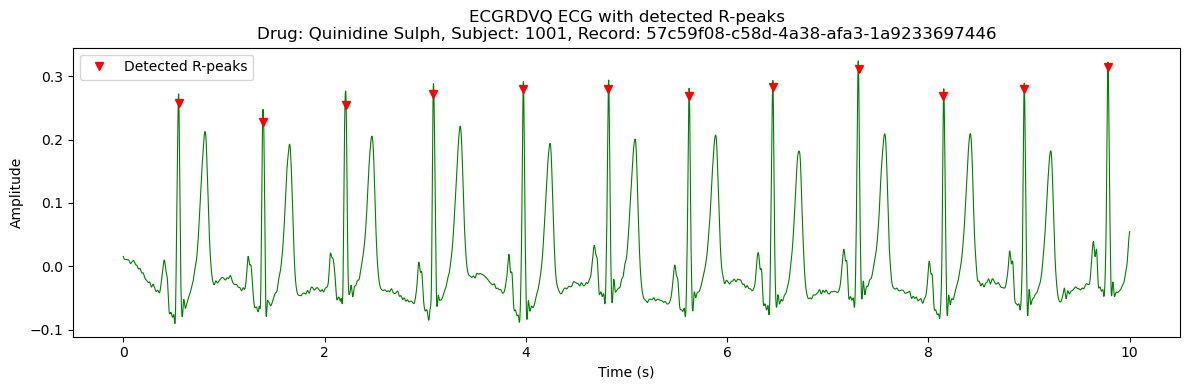

In [34]:
# Show a 10-second window with detected R-peaks
show_sec = 10
show_samples = int(show_sec * fs)
t = np.arange(show_samples) / fs

peaks_window = r_peaks[r_peaks < show_samples]

plt.figure(figsize=(12, 4))
plt.plot(t, clean_signal[:show_samples], 'green', linewidth=0.8)
plt.plot(peaks_window / fs, clean_signal[peaks_window], 'rv', label="Detected R-peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(
    f"ECGRDVQ ECG with detected R-peaks\n"
    f"Drug: {info['drug']}, Subject: {info['subject_id']}, Record: {info['record_id']}"
)
plt.legend()
plt.tight_layout()
plt.show()